In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load ONLY the clean data we just created
df_clean = pd.read_csv('clean_air_raid_data.csv')

# Verify it loaded perfectly
print(f"Loaded {len(df_clean)} clean rows for visualization.")
display(df_clean.head(3))

Matplotlib is building the font cache; this may take a moment.


Loaded 158049 clean rows for visualization.


,oblast,raion,hromada,level,started_at,finished_at,source,duration_minutes,start_hour,year_month
0,Vinnytska oblast,NaN,NaN,oblast,2022-03-15 16:10:34+00:00,2022-03-15 16:50:07+00:00,official,39.550000,16,2022-03
1,Zhytomyrska oblast,NaN,NaN,oblast,2022-03-15 16:11:25+00:00,2022-03-15 16:54:23+00:00,official,42.966667,16,2022-03
2,Cherkaska oblast,Umanskyi raion,Umanska terytorialna hromada,hromada,2022-03-15 16:11:50+00:00,2022-03-15 16:54:47+00:00,official,42.950000,16,2022-03


In [2]:
# 1. Re-awaken the datetime columns (fixing the CSV amnesia)
df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])
df_clean['finished_at'] = pd.to_datetime(df_clean['finished_at'])

# 2. Verify that the computer now recognizes them as numbers/dates, not text
print("--- DATA FORMAT CHECK ---")
print(df_clean[['started_at', 'duration_minutes', 'start_hour']].dtypes)

print("\n✅ Verification Complete: The data is clean, readable, and perfectly formatted.")

--- DATA FORMAT CHECK ---
started_at          datetime64[us, UTC]
duration_minutes                float64
start_hour                        int64
dtype: object

✅ Verification Complete: The data is clean, readable, and perfectly formatted.


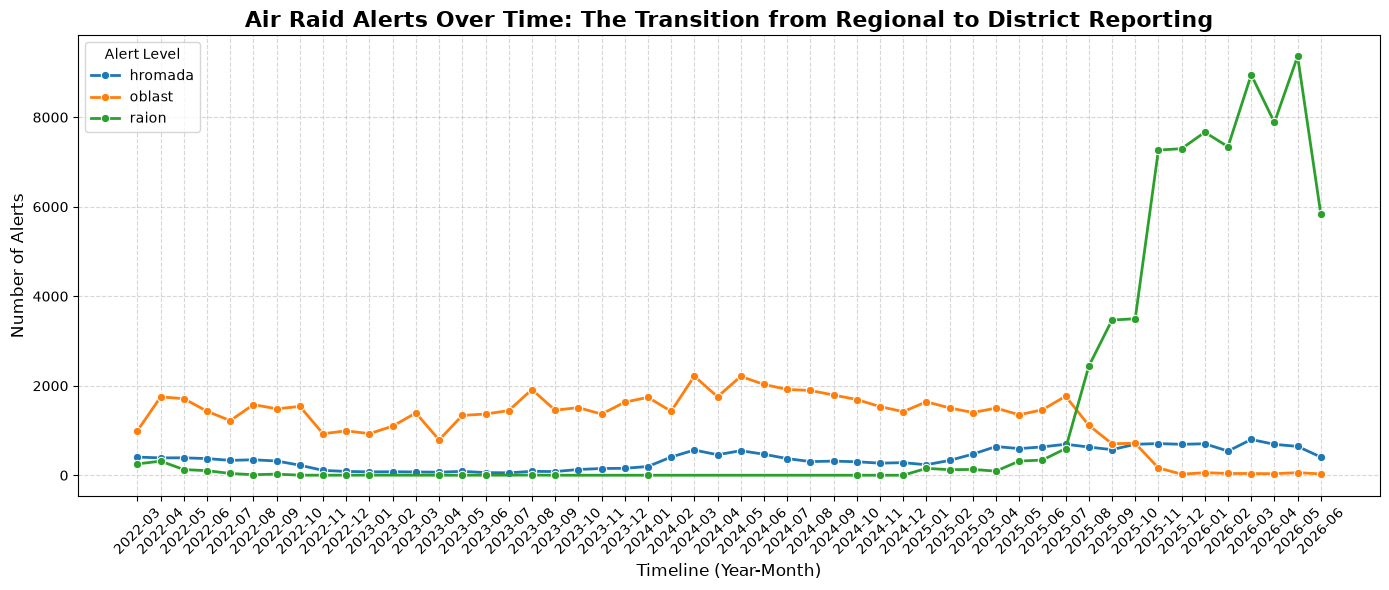

In [3]:
# --- PART 1: THE TIMELINE & POLICY SHIFT ---

# Group by Year-Month and Level, and count the occurrences
monthly_trend = df_clean.groupby(['year_month', 'level']).size().reset_index(name='alert_count')

# Set up a large, wide canvas for a timeline
plt.figure(figsize=(14, 6))

# Draw the line chart, separating the lines by the 'level' column
sns.lineplot(data=monthly_trend, x='year_month', y='alert_count', hue='level', marker="o", linewidth=2)

# Professional Formatting
plt.title("Air Raid Alerts Over Time: The Transition from Regional to District Reporting", fontsize=16, fontweight="bold")
plt.xlabel("Timeline (Year-Month)", fontsize=12)
plt.ylabel("Number of Alerts", fontsize=12)

# Rotate the dates on the bottom so they are easy to read
plt.xticks(rotation=45)
plt.legend(title="Alert Level")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# Display the chart
plt.show()

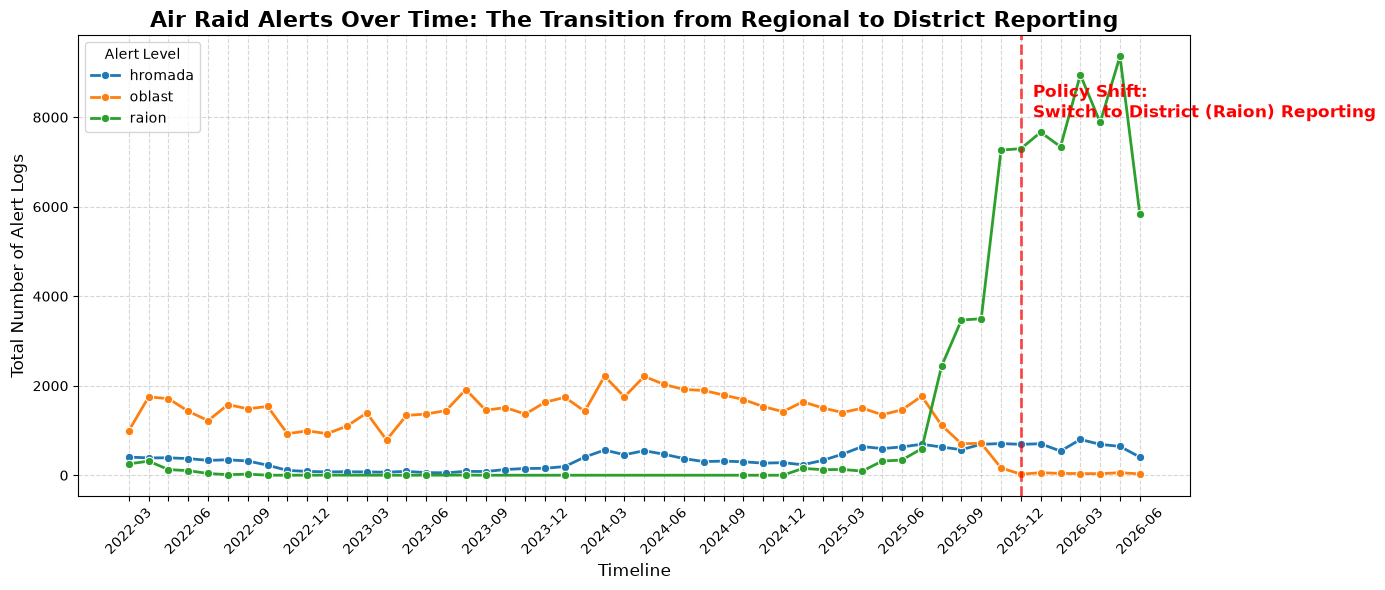

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a large, wide canvas
plt.figure(figsize=(14, 6))

# Draw the line chart
sns.lineplot(data=monthly_trend, x='year_month', y='alert_count', hue='level', marker="o", linewidth=2)

# --- THE ANALYST'S UPGRADE: ADDING CONTEXT ---

# 1. Draw a vertical red dashed line exactly at December 2025
plt.axvline(x='2025-12', color='red', linestyle='--', linewidth=2, alpha=0.7)

# 2. Add text right next to the line to explain it to the reader
plt.text(x='2025-12', y=8000, s='  Policy Shift:\n  Switch to District (Raion) Reporting', 
         color='red', fontsize=12, fontweight='bold')

# 3. Clean up the X-Axis so it isn't so crowded (Show every 3rd month)
ax = plt.gca() # Get current axis
for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % 3 != 0: # Hide the label if it's not a multiple of 3
        label.set_visible(False)

# --- PROFESSIONAL FORMATTING ---
plt.title("Air Raid Alerts Over Time: The Transition from Regional to District Reporting", fontsize=16, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Total Number of Alert Logs", fontsize=12) # Changed label to be more accurate

plt.xticks(rotation=45)
plt.legend(title="Alert Level", loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# Display the chart
plt.show()

Running Time-Union Algorithm to collapse overlaps... This might take a few seconds.


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_61750/428785203.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  true_alerts['year_month'] = true_alerts['true_start'].dt.to_period('M').astype(str)


Algorithm complete! Drawing the true timeline...


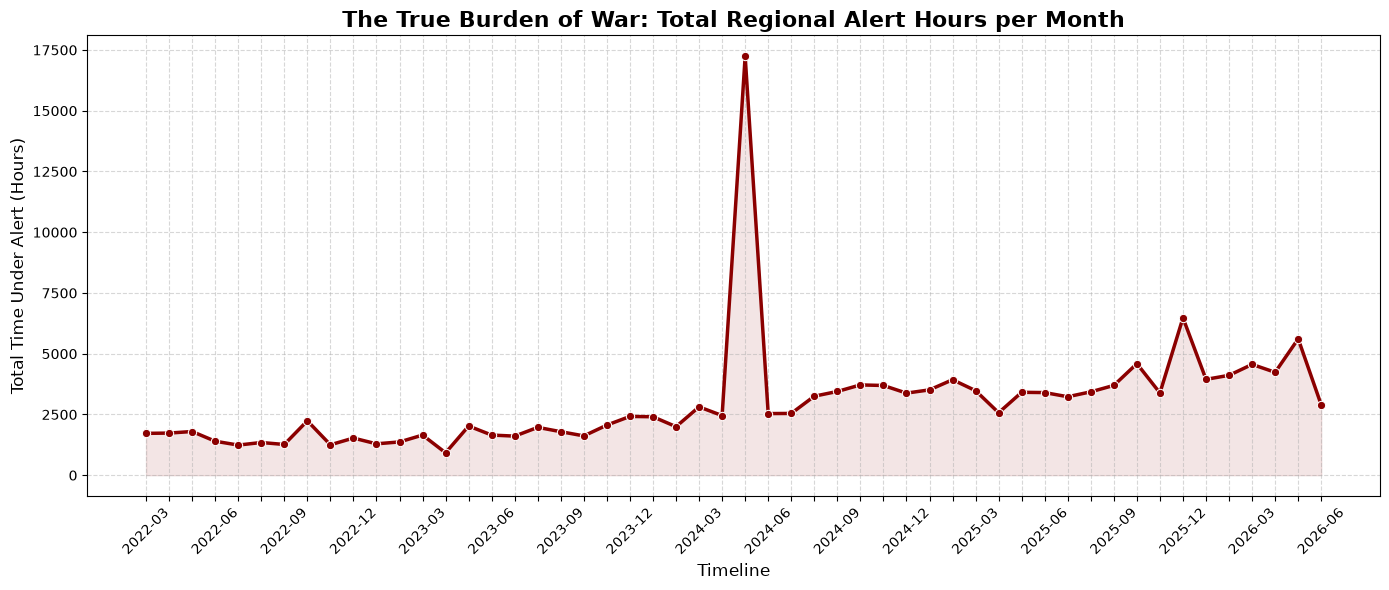

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Running Time-Union Algorithm to collapse overlaps... This might take a few seconds.")

# --- THE DATA ENGINEERING (Collapsing Overlaps) ---

# 1. Sort the data perfectly by Region and Time
temp_df = df_clean.sort_values(['oblast', 'started_at']).copy()

# 2. Find overlapping times (If district alerts fire at the same time, group them)
temp_df['max_end_so_far'] = temp_df.groupby('oblast')['finished_at'].cummax().shift()
temp_df['max_end_so_far'] = temp_df['max_end_so_far'].fillna(temp_df['started_at'])
temp_df['is_new_alert'] = temp_df['started_at'] > temp_df['max_end_so_far']
temp_df['alert_id'] = temp_df.groupby('oblast')['is_new_alert'].cumsum()

# 3. Merge them together to get the "True Wall-Clock" start and end times
true_alerts = temp_df.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

# 4. Calculate the true duration in Hours
true_alerts['true_duration_hours'] = (true_alerts['true_end'] - true_alerts['true_start']).dt.total_seconds() / 3600

# 5. Group by Month to get the final national timeline
true_alerts['year_month'] = true_alerts['true_start'].dt.to_period('M').astype(str)
final_timeline = true_alerts.groupby('year_month')['true_duration_hours'].sum().reset_index()

print("Algorithm complete! Drawing the true timeline...")

# --- THE VISUALIZATION ---

plt.figure(figsize=(14, 6))

# Draw the single, undeniable line representing total hours
sns.lineplot(data=final_timeline, x='year_month', y='true_duration_hours', marker="o", color="darkred", linewidth=2.5)

# Professional Formatting
plt.title("The True Burden of War: Total Regional Alert Hours per Month", fontsize=16, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Total Time Under Alert (Hours)", fontsize=12)

# Clean up the X-Axis so we only show every 3rd month
ax = plt.gca()
for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % 3 != 0: 
        label.set_visible(False)

# Add grid, rotate dates, and fill the area underneath for a polished look
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.fill_between(final_timeline['year_month'], final_timeline['true_duration_hours'], color="darkred", alpha=0.1)
plt.tight_layout()

# Display the chart
plt.show()

In [6]:
# 1. Sort the clean dataset to find the alerts with the largest durations
longest_alerts = df_clean.sort_values(by='duration_minutes', ascending=False).copy()

# 2. Convert the minutes into days for easier reading
longest_alerts['duration_days'] = longest_alerts['duration_minutes'] / 60 / 24

# 3. Print the top 10 longest alerts in the entire war
print("--- THE 10 LONGEST ALERTS IN THE DATABASE ---")
display(longest_alerts[['oblast', 'raion', 'started_at', 'finished_at', 'duration_days', 'level']].head(10))

--- THE 10 LONGEST ALERTS IN THE DATABASE ---


,oblast,raion,started_at,finished_at,duration_days,level
44603,Kharkivska oblast,Kharkivskyi raion,2024-05-12 08:37:29+00:00,2026-01-06 09:53:57+00:00,604.053102,hromada
45324,Kharkivska oblast,Chuhuivskyi raion,2024-05-20 09:31:41+00:00,2025-08-01 22:52:43+00:00,438.556273,hromada
138231,Dnipropetrovska oblast,Nikopolskyi raion,2026-03-23 21:53:07+00:00,2026-04-19 05:12:29+00:00,26.305116,hromada
64679,Dnipropetrovska oblast,Nikopolskyi raion,2025-02-24 14:01:55+00:00,2025-03-17 03:07:56+00:00,20.545845,hromada
129915,Dnipropetrovska oblast,Nikopolskyi raion,2026-03-03 20:50:20+00:00,2026-03-23 17:54:21+00:00,19.877789,hromada
61721,Dnipropetrovska oblast,Nikopolskyi raion,2025-01-12 07:37:02+00:00,2025-01-25 06:46:14+00:00,12.964722,hromada
67440,Dnipropetrovska oblast,Nikopolskyi raion,2025-04-07 10:50:26+00:00,2025-04-20 05:27:01+00:00,12.775405,hromada
123534,Dnipropetrovska oblast,Nikopolskyi raion,2026-02-21 09:46:42+00:00,2026-03-02 17:20:09+00:00,9.314896,hromada
119266,Dnipropetrovska oblast,Nikopolskyi raion,2026-02-05 20:08:27+00:00,2026-02-14 07:37:42+00:00,8.478646,hromada
60053,Dnipropetrovska oblast,Nikopolskyi raion,2024-12-15 11:52:36+00:00,2024-12-23 09:49:58+00:00,7.914838,hromada


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Filtering outliers and running Time-Union Algorithm... Please wait.")

# --- THE FIX: REMOVE OUTLIERS ---
# Only keep alerts that lasted less than 24 hours (1 day)
df_standard = df_clean[df_clean['duration_days'] < 1].copy()

# --- THE DATA ENGINEERING (Collapsing Overlaps) ---
temp_df = df_standard.sort_values(['oblast', 'started_at']).copy()

temp_df['max_end_so_far'] = temp_df.groupby('oblast')['finished_at'].cummax().shift()
temp_df['max_end_so_far'] = temp_df['max_end_so_far'].fillna(temp_df['started_at'])
temp_df['is_new_alert'] = temp_df['started_at'] > temp_df['max_end_so_far']
temp_df['alert_id'] = temp_df.groupby('oblast')['is_new_alert'].cumsum()

true_alerts = temp_df.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

true_alerts['true_duration_hours'] = (true_alerts['true_end'] - true_alerts['true_start']).dt.total_seconds() / 3600

# Group by Month to get the final national timeline
true_alerts['year_month'] = true_alerts['true_start'].dt.to_period('M').astype(str)
final_timeline = true_alerts.groupby('year_month')['true_duration_hours'].sum().reset_index()

# --- THE VISUALIZATION ---
plt.figure(figsize=(14, 6))

sns.lineplot(data=final_timeline, x='year_month', y='true_duration_hours', marker="o", color="darkred", linewidth=2.5)

plt.title("The True Burden of War: Total Regional Alert Hours per Month (Standard Alerts < 24h)", fontsize=16, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Total Time Under Alert (Hours)", fontsize=12)

ax = plt.gca()
for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % 3 != 0: 
        label.set_visible(False)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.fill_between(final_timeline['year_month'], final_timeline['true_duration_hours'], color="darkred", alpha=0.1)
plt.tight_layout()

plt.show()

Filtering outliers and running Time-Union Algorithm... Please wait.


KeyError: 'duration_days'

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Filtering outliers and running Time-Union Algorithm... Please wait.")

# --- THE FIX: REMOVE OUTLIERS ---
# Only keep alerts that lasted less than 24 hours (1 day)
df_standard = df_clean[df_clean['duration_days'] < 1].copy()

# --- THE DATA ENGINEERING (Collapsing Overlaps) ---
temp_df = df_standard.sort_values(['oblast', 'started_at']).copy()

temp_df['max_end_so_far'] = temp_df.groupby('oblast')['finished_at'].cummax().shift()
temp_df['max_end_so_far'] = temp_df['max_end_so_far'].fillna(temp_df['started_at'])
temp_df['is_new_alert'] = temp_df['started_at'] > temp_df['max_end_so_far']
temp_df['alert_id'] = temp_df.groupby('oblast')['is_new_alert'].cumsum()

true_alerts = temp_df.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

true_alerts['true_duration_hours'] = (true_alerts['true_end'] - true_alerts['true_start']).dt.total_seconds() / 3600

# Group by Month to get the final national timeline
true_alerts['year_month'] = true_alerts['true_start'].dt.to_period('M').astype(str)
final_timeline = true_alerts.groupby('year_month')['true_duration_hours'].sum().reset_index()

print("Algorithm complete! Drawing the true timeline...")

# --- THE VISUALIZATION ---
plt.figure(figsize=(14, 6))

sns.lineplot(data=final_timeline, x='year_month', y='true_duration_hours', marker="o", color="darkred", linewidth=2.5)

plt.title("The True Burden of War: Total Regional Alert Hours per Month (Standard Alerts < 24h)", fontsize=16, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Total Time Under Alert (Hours)", fontsize=12)

ax = plt.gca()
for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % 3 != 0: 
        label.set_visible(False)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.fill_between(final_timeline['year_month'], final_timeline['true_duration_hours'], color="darkred", alpha=0.1)
plt.tight_layout()

plt.show()

Filtering outliers and running Time-Union Algorithm... Please wait.


KeyError: 'duration_days'

Filtering outliers and running Time-Union Algorithm... Please wait.
Algorithm complete! Drawing the true timeline...


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_61750/2790930446.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  true_alerts['year_month'] = true_alerts['true_start'].dt.to_period('M').astype(str)


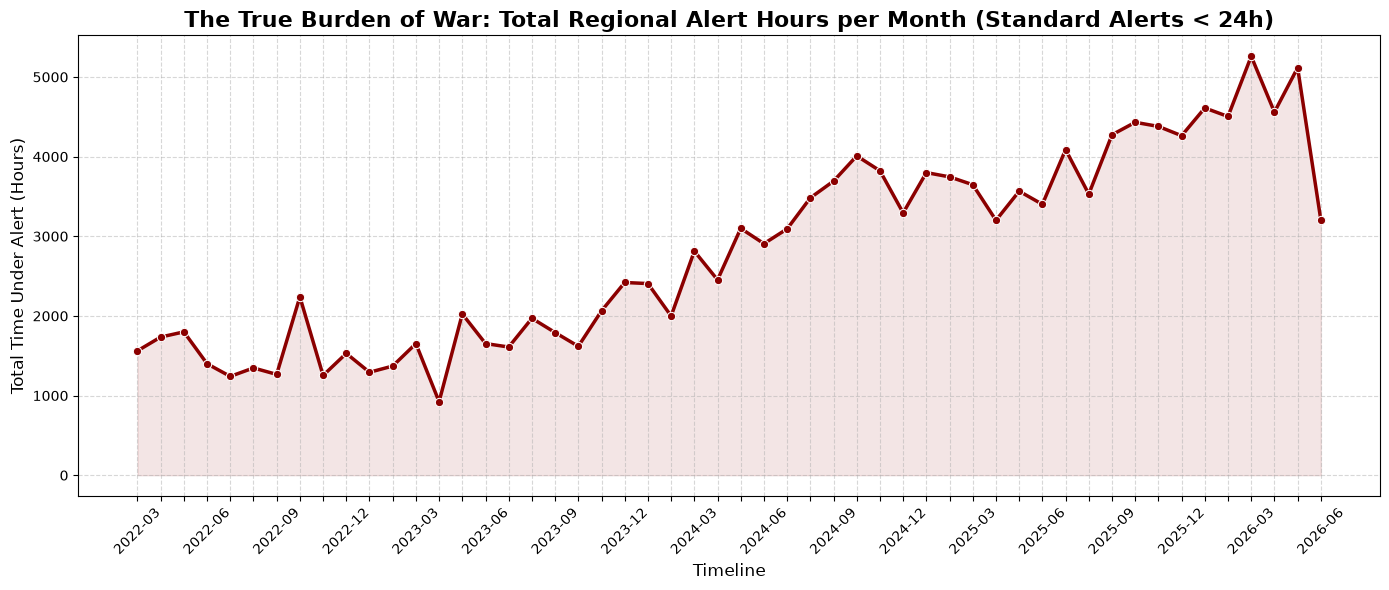

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Filtering outliers and running Time-Union Algorithm... Please wait.")

# --- THE FIX: REMOVE OUTLIERS ---
# Only keep alerts that lasted less than 24 hours (1440 minutes)
# We use duration_minutes because we know it already exists in df_clean!
df_standard = df_clean[df_clean['duration_minutes'] < 1440].copy()

# --- THE DATA ENGINEERING (Collapsing Overlaps) ---
temp_df = df_standard.sort_values(['oblast', 'started_at']).copy()

temp_df['max_end_so_far'] = temp_df.groupby('oblast')['finished_at'].cummax().shift()
temp_df['max_end_so_far'] = temp_df['max_end_so_far'].fillna(temp_df['started_at'])
temp_df['is_new_alert'] = temp_df['started_at'] > temp_df['max_end_so_far']
temp_df['alert_id'] = temp_df.groupby('oblast')['is_new_alert'].cumsum()

true_alerts = temp_df.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

true_alerts['true_duration_hours'] = (true_alerts['true_end'] - true_alerts['true_start']).dt.total_seconds() / 3600

# Group by Month to get the final national timeline
true_alerts['year_month'] = true_alerts['true_start'].dt.to_period('M').astype(str)
final_timeline = true_alerts.groupby('year_month')['true_duration_hours'].sum().reset_index()

print("Algorithm complete! Drawing the true timeline...")

# --- THE VISUALIZATION ---
plt.figure(figsize=(14, 6))

sns.lineplot(data=final_timeline, x='year_month', y='true_duration_hours', marker="o", color="darkred", linewidth=2.5)

plt.title("The True Burden of War: Total Regional Alert Hours per Month (Standard Alerts < 24h)", fontsize=16, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Total Time Under Alert (Hours)", fontsize=12)

ax = plt.gca()
for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % 3 != 0: 
        label.set_visible(False)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.fill_between(final_timeline['year_month'], final_timeline['true_duration_hours'], color="darkred", alpha=0.1)
plt.tight_layout()

plt.show()

Converting to local time and analyzing tactical patterns...


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_61750/655384637.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_pattern, x='hour_of_day', y='attack_count', palette=colors)


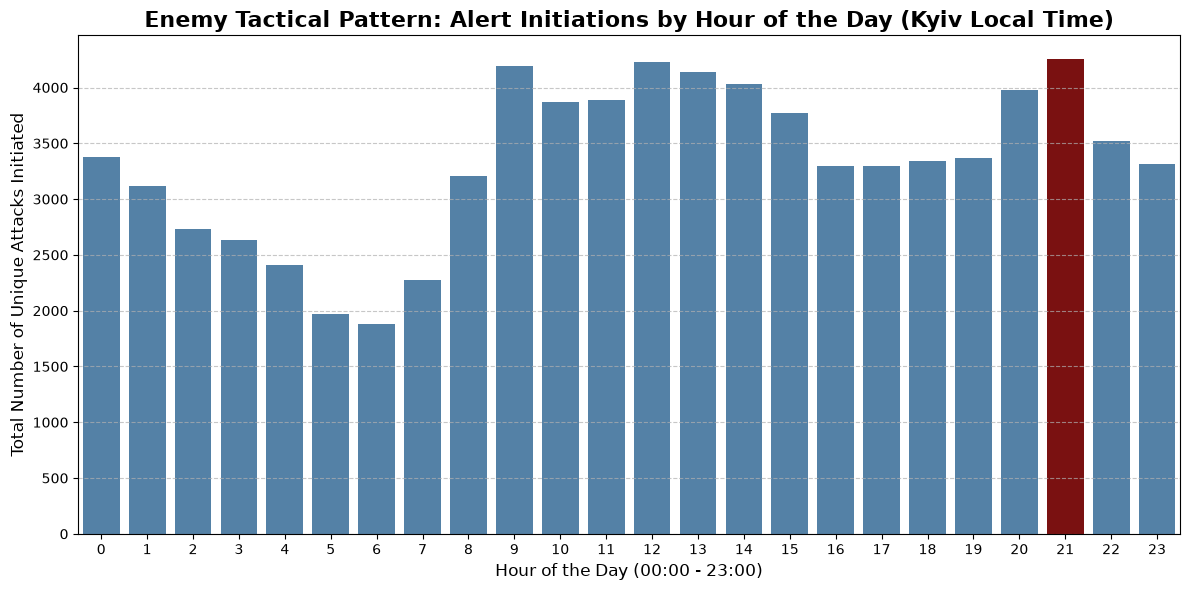

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Converting to local time and analyzing tactical patterns...")

# --- THE DATA ENGINEERING ---

# 1. Convert the UTC computer time to actual Ukrainian local time
true_alerts['kyiv_time'] = true_alerts['true_start'].dt.tz_convert('Europe/Kyiv')

# 2. Extract strictly the hour of the day the attack was INITIATED (0 to 23)
true_alerts['hour_of_day'] = true_alerts['kyiv_time'].dt.hour

# 3. Count how many unique attacks were launched during each hour over the whole war
hourly_pattern = true_alerts.groupby('hour_of_day').size().reset_index(name='attack_count')

# --- THE VISUALIZATION ---

plt.figure(figsize=(12, 6))

# 4. Find the absolute peak hour so we can highlight it visually
peak_hour = hourly_pattern['attack_count'].max()
colors = ['darkred' if count == peak_hour else 'steelblue' for count in hourly_pattern['attack_count']]

# Draw the bar chart
sns.barplot(data=hourly_pattern, x='hour_of_day', y='attack_count', palette=colors)

# Professional Formatting
plt.title("Enemy Tactical Pattern: Alert Initiations by Hour of the Day (Kyiv Local Time)", fontsize=16, fontweight="bold")
plt.xlabel("Hour of the Day (00:00 - 23:00)", fontsize=12)
plt.ylabel("Total Number of Unique Attacks Initiated", fontsize=12)

# Add gridlines to make it easy to read across
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()

# Display the chart
plt.show()

In [12]:
# --- NUMERIC SANITY CHECK ---

print("--- TOP 3 BUSIEST HOURS (Check against the highest bars) ---")
display(hourly_pattern.sort_values(by='attack_count', ascending=False).head(3))

print("\n--- TOP 3 QUIETEST HOURS (Check against the lowest bars) ---")
display(hourly_pattern.sort_values(by='attack_count', ascending=True).head(3))

--- TOP 3 BUSIEST HOURS (Check against the highest bars) ---


,hour_of_day,attack_count
21,21,4255
12,12,4228
9,9,4194



--- TOP 3 QUIETEST HOURS (Check against the lowest bars) ---


,hour_of_day,attack_count
6,6,1884
5,5,1967
7,7,2272


Processing geographic data and building split-pane dashboard...
Dashboard rendering...


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_61750/29360591.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_ranking.head(15), x='true_hours', y='oblast', palette="Reds_r", ax=ax_main)


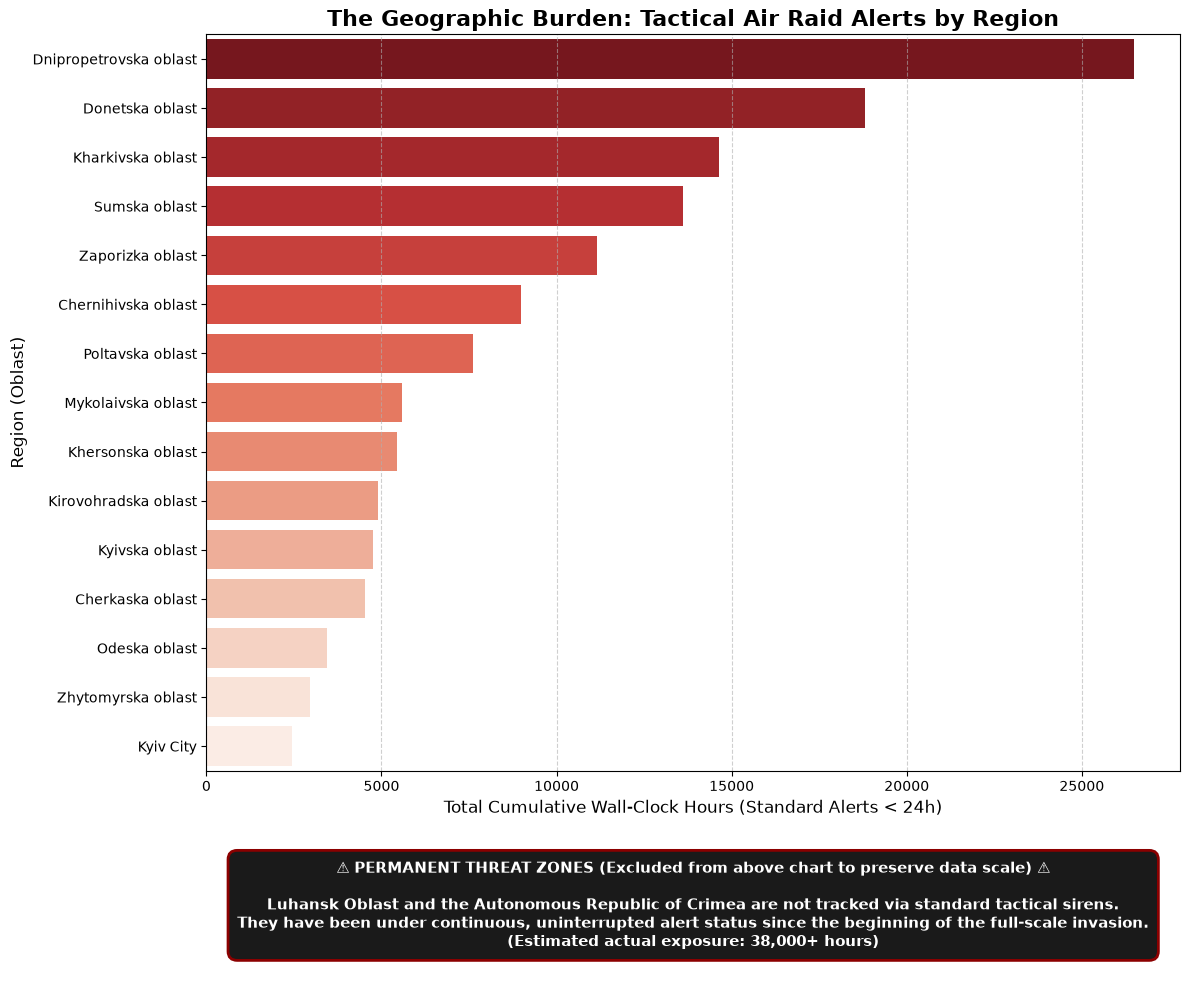

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Processing geographic data and building split-pane dashboard...")

# --- THE DATA ENGINEERING ---

# 1. Isolate standard tactical alerts (under 24 hours)
df_geo_clean = df_clean[df_clean['duration_minutes'] < 1440].copy()

# 2. Sort and prepare for interval union
temp_geo = df_geo_clean.sort_values(['oblast', 'started_at']).copy()

# 3. Collapse overlaps into a single regional clock
temp_geo['max_end_so_far'] = temp_geo.groupby('oblast')['finished_at'].cummax().shift()
temp_geo['max_end_so_far'] = temp_geo['max_end_so_far'].fillna(temp_geo['started_at'])
temp_geo['is_new_alert'] = temp_geo['started_at'] > temp_geo['max_end_so_far']
temp_geo['alert_id'] = temp_geo.groupby('oblast')['is_new_alert'].cumsum()

collapsed_geo = temp_geo.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

# 4. Calculate total hours and rank regions
collapsed_geo['true_hours'] = (collapsed_geo['true_end'] - collapsed_geo['true_start']).dt.total_seconds() / 3600
geo_ranking = collapsed_geo.groupby('oblast')['true_hours'].sum().reset_index()
geo_ranking = geo_ranking.sort_values(by='true_hours', ascending=False)

print("Dashboard rendering...")

# --- THE VISUALIZATION (Split-Pane Layout) ---

# Create a figure with 2 sections. 
# 'height_ratios: [5, 1]' means the top chart gets 5x more space than the bottom banner.
fig, (ax_main, ax_perm) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [5, 1]})

# --- PANE 1: The Standard Leaderboard ---
sns.barplot(data=geo_ranking.head(15), x='true_hours', y='oblast', palette="Reds_r", ax=ax_main)
ax_main.set_title("The Geographic Burden: Tactical Air Raid Alerts by Region", fontsize=16, fontweight="bold")
ax_main.set_xlabel("Total Cumulative Wall-Clock Hours (Standard Alerts < 24h)", fontsize=12)
ax_main.set_ylabel("Region (Oblast)", fontsize=12)
ax_main.grid(axis='x', linestyle='--', alpha=0.6)

# --- PANE 2: The Permanent Regions Tracker ---
ax_perm.axis('off') # Hide the standard chart borders for this section

# Create a highly visible, styled black box with red borders for the missing/permanent regions
bbox_props = dict(boxstyle="round,pad=0.6", fc="#1a1a1a", ec="darkred", lw=2)
ax_perm.text(0.5, 0.5, 
             "⚠️ PERMANENT THREAT ZONES (Excluded from above chart to preserve data scale) ⚠️\n\n"
             "Luhansk Oblast and the Autonomous Republic of Crimea are not tracked via standard tactical sirens.\n"
             "They have been under continuous, uninterrupted alert status since the beginning of the full-scale invasion.\n"
             "(Estimated actual exposure: 38,000+ hours)",
             ha="center", va="center", fontsize=11, color="white", bbox=bbox_props, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# --- GEOGRAPHIC SANITY CHECK ---

print("--- TOP 5 HARDEST-HIT REGIONS ---")
print("Verify these numbers match the longest bars at the top of your chart:")
display(geo_ranking.head(5))

print("\n--- BOTTOM 5 SAFEST REGIONS ---")
print("Verify these numbers match the shortest bars (or regions excluded from the top 15):")
display(geo_ranking.tail(5))

--- TOP 5 HARDEST-HIT REGIONS ---
Verify these numbers match the longest bars at the top of your chart:


,oblast,true_hours
3,Dnipropetrovska oblast,26479.565000
4,Donetska oblast,18800.452778
6,Kharkivska oblast,14644.273889
17,Sumska oblast,13624.616111
22,Zaporizka oblast,11159.845556



--- BOTTOM 5 SAFEST REGIONS ---
Verify these numbers match the shortest bars (or regions excluded from the top 15):


,oblast,true_hours
2,Chernivetska oblast,993.815556
20,Volynska oblast,992.047500
5,Ivano-Frankivska oblast,912.134722
12,Lvivska oblast,909.216667
21,Zakarpatska oblast,769.411944


Re-collapsing intervals to ensure pure event-level durations...
Data processing complete! Generating duration profile...


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_61750/48058439.py:68: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/Yevhenii/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


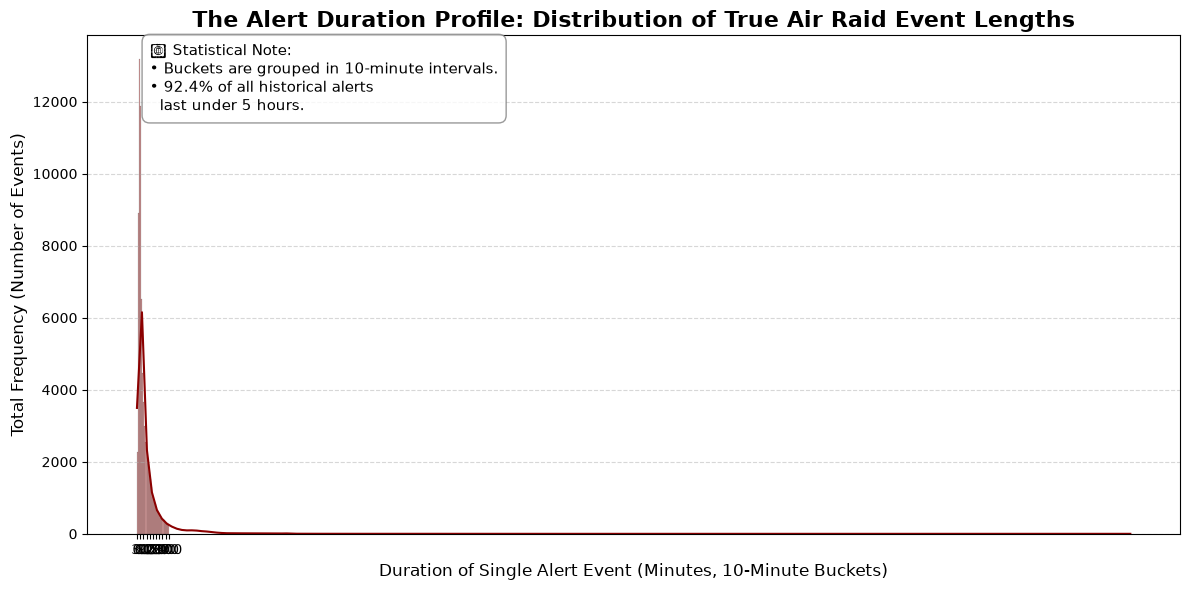

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Re-collapsing intervals to ensure pure event-level durations...")

# --- THE DATA ENGINEERING (Pure Single-Denominator Events) ---

# 1. Isolate standard tactical alerts under 24 hours
df_dur_clean = df_clean[df_clean['duration_minutes'] < 1440].copy()

# 2. Run the Time-Union sorting and grouping to collapse concurrent district logs
temp_dur = df_dur_clean.sort_values(['oblast', 'started_at']).copy()
temp_dur['max_end_so_far'] = temp_dur.groupby('oblast')['finished_at'].cummax().shift()
temp_dur['max_end_so_far'] = temp_dur['max_end_so_far'].fillna(temp_dur['started_at'])
temp_dur['is_new_alert'] = temp_dur['started_at'] > temp_dur['max_end_so_far']
temp_dur['alert_id'] = temp_dur.groupby('oblast')['is_new_alert'].cumsum()

collapsed_dur = temp_dur.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

# 3. Calculate true duration directly in minutes for granular tracking
collapsed_dur['true_duration_minutes'] = (collapsed_dur['true_end'] - collapsed_dur['true_start']).dt.total_seconds() / 60

# 4. Remove zero-minute system testing glitches or negative clock anomalies
collapsed_dur = collapsed_dur[collapsed_dur['true_duration_minutes'] > 0]

print("Data processing complete! Generating duration profile...")

# --- THE VISUALIZATION ---

plt.figure(figsize=(12, 6))

# 5. Draw the histogram using 10-minute buckets, capping the horizontal axis at 300 minutes (5 hours)
# We add the KDE (Kernel Density Estimate) line to show the smooth mathematical trend curve over the bars
sns.histplot(
    data=collapsed_dur, 
    x='true_duration_minutes', 
    binwidth=10, 
    binrange=(0, 300), 
    color="darkred", 
    alpha=0.4, 
    kde=True
)

# Professional Formatting
plt.title("The Alert Duration Profile: Distribution of True Air Raid Event Lengths", fontsize=16, fontweight="bold")
plt.xlabel("Duration of Single Alert Event (Minutes, 10-Minute Buckets)", fontsize=12)
plt.ylabel("Total Frequency (Number of Events)", fontsize=12)

# Set precise tick marks every 30 minutes on the bottom axis for fast cross-referencing
plt.xticks(range(0, 301, 30))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Calculate what percentage of alerts sit safely within our 5-hour display window for transparency
pct_within_window = (len(collapsed_dur[collapsed_dur['true_duration_minutes'] <= 300]) / len(collapsed_dur)) * 100

# Add a statistical note to the chart explaining the methodology
plt.text(x=120, y=plt.gca().get_ylim()[1] * 0.85, 
         s=f"📊 Statistical Note:\n"
           f"• Buckets are grouped in 10-minute intervals.\n"
           f"• {pct_within_window:.1f}% of all historical alerts\n"
           f"  last under 5 hours.", 
         fontsize=11, color="black", bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

Re-engineering duration data with hard boundaries...
Generating clean, readable duration profile...


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_61750/163561625.py:67: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/Yevhenii/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


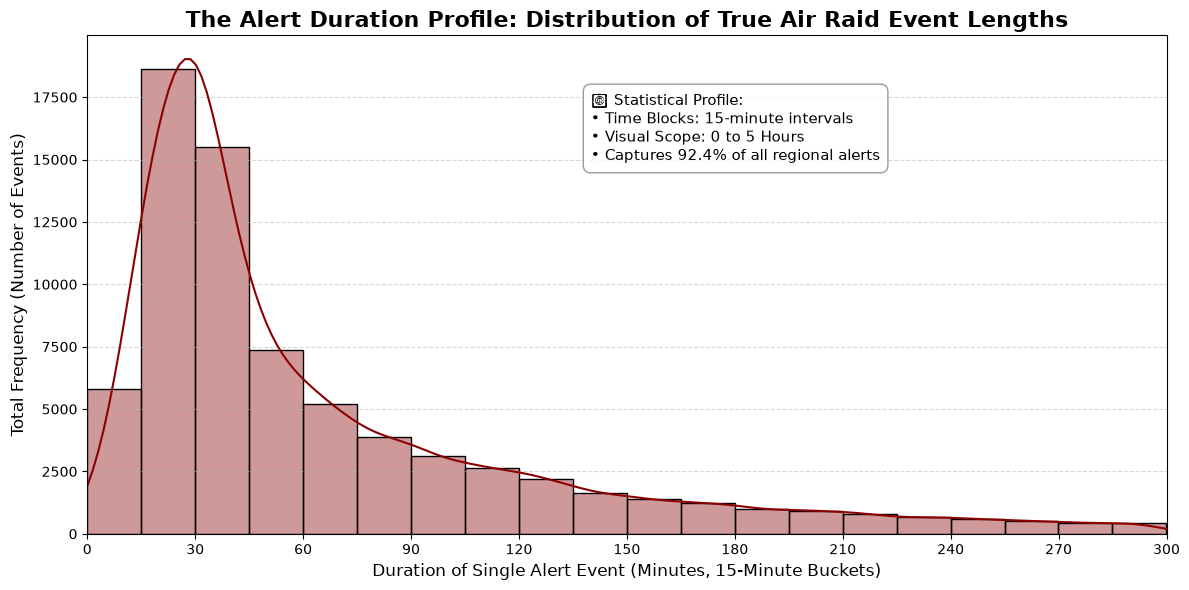

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Re-engineering duration data with hard boundaries...")

# --- DATA CLEANING & RE-FILTERING ---
# 1. Isolate standard tactical alerts under 24 hours from raw data
df_dur_clean = df_clean[df_clean['duration_minutes'] < 1440].copy()

# 2. Run Time-Union to collapse overlapping district sirens
temp_dur = df_dur_clean.sort_values(['oblast', 'started_at']).copy()
temp_dur['max_end_so_far'] = temp_dur.groupby('oblast')['finished_at'].cummax().shift()
temp_dur['max_end_so_far'] = temp_dur['max_end_so_far'].fillna(temp_dur['started_at'])
temp_dur['is_new_alert'] = temp_dur['started_at'] > temp_dur['max_end_so_far']
temp_dur['alert_id'] = temp_dur.groupby('oblast')['is_new_alert'].cumsum()

collapsed_dur = temp_dur.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

collapsed_dur['true_duration_minutes'] = (collapsed_dur['true_end'] - collapsed_dur['true_start']).dt.total_seconds() / 60

# 3. STRICT FILTER: Isolate standard tactical alerts (0 to 5 hours) to prevent axis blowout
df_visual = collapsed_dur[(collapsed_dur['true_duration_minutes'] > 0) & (collapsed_dur['true_duration_minutes'] <= 300)].copy()

print("Generating clean, readable duration profile...")

# --- THE VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Plot with 15-minute intervals (periods longer than 10 mins)
sns.histplot(
    data=df_visual, 
    x='true_duration_minutes', 
    binwidth=15, 
    color="darkred", 
    alpha=0.4, 
    kde=True
)

# Hard boundary control to fix the squishing issue seen in image_08b7bc.png
plt.xlim(0, 300)

# Formatting and labeling
plt.title("The Alert Duration Profile: Distribution of True Air Raid Event Lengths", fontsize=16, fontweight="bold")
plt.xlabel("Duration of Single Alert Event (Minutes, 15-Minute Buckets)", fontsize=12)
plt.ylabel("Total Frequency (Number of Events)", fontsize=12)

# Set grid lines and ticks at clean 30-minute markers for easy readability
plt.xticks(range(0, 301, 30))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Clear statistical context box
total_alerts = len(collapsed_dur)
captured_alerts = len(df_visual)
pct_captured = (captured_alerts / total_alerts) * 100

plt.text(x=140, y=plt.gca().get_ylim()[1] * 0.75, 
         s=f"📊 Statistical Profile:\n"
           f"• Time Blocks: 15-minute intervals\n"
           f"• Visual Scope: 0 to 5 Hours\n"
           f"• Captures {pct_captured:.1f}% of all regional alerts", 
         fontsize=11, color="black", bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

# --- DURATION SANITY CHECK ---
print("--- THE MOST COMMON ALERT DURATIONS (15-Minute Buckets) ---")
print("Verify that the top buckets here match the tallest bars on your chart:\n")

# Group the exact durations into the 15-minute buckets used by the chart
bins = range(0, 315, 15)
bucket_counts = pd.cut(df_visual['true_duration_minutes'], bins=bins).value_counts()

# Create a clean table for you to read
sanity_table = bucket_counts.reset_index()
sanity_table.columns = ['Duration Bucket (Minutes)', 'Total Number of Alerts']

# Display the top 5 most frequent buckets
display(sanity_table.head(5))

--- THE MOST COMMON ALERT DURATIONS (15-Minute Buckets) ---
Verify that the top buckets here match the tallest bars on your chart:



,Duration Bucket (Minutes),Total Number of Alerts
0,"(15, 30]",18601
1,"(30, 45]",15524
2,"(45, 60]",7377
3,"(0, 15]",5793
4,"(60, 75]",5226
